In [12]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv("/home/silvy_linux/Desktop/Internship/Datasets/car_price_prediction_.csv")

# Display first 5 rows
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [14]:
print(df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDataset Info:\n")
print(df.info())

(2500, 10)

Columns:

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='str')

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 195.4 KB
None


In [15]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [16]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [17]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (2500, 10)


In [18]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (2500, 10)


In [19]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [20]:
df.dtypes

Car ID            int64
Brand               str
Year              int64
Engine Size     float64
Fuel Type           str
Transmission        str
Mileage           int64
Condition           str
Price           float64
Model               str
dtype: object

In [21]:
df.drop("Car ID", axis=1, inplace=True)   #remove car id cause we already have index as pandas unique

df.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [22]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='str')


In [23]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,5,2016,2.3,3,1,114832,1,26613.92,19
1,1,2018,4.4,1,1,143190,2,14679.61,1
2,0,2013,4.5,1,1,181601,1,44402.61,3
3,5,2011,4.1,0,0,68682,1,86374.33,20
4,2,2009,2.6,0,1,223009,0,73577.10,21


In [24]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,5,2016,2.3,3,1,114832,1,26613.92,19
1,1,2018,4.4,1,1,143190,2,14679.61,1
2,0,2013,4.5,1,1,181601,1,44402.61,3
3,5,2011,4.1,0,0,68682,1,86374.33,20
4,2,2009,2.6,0,1,223009,0,73577.10,21


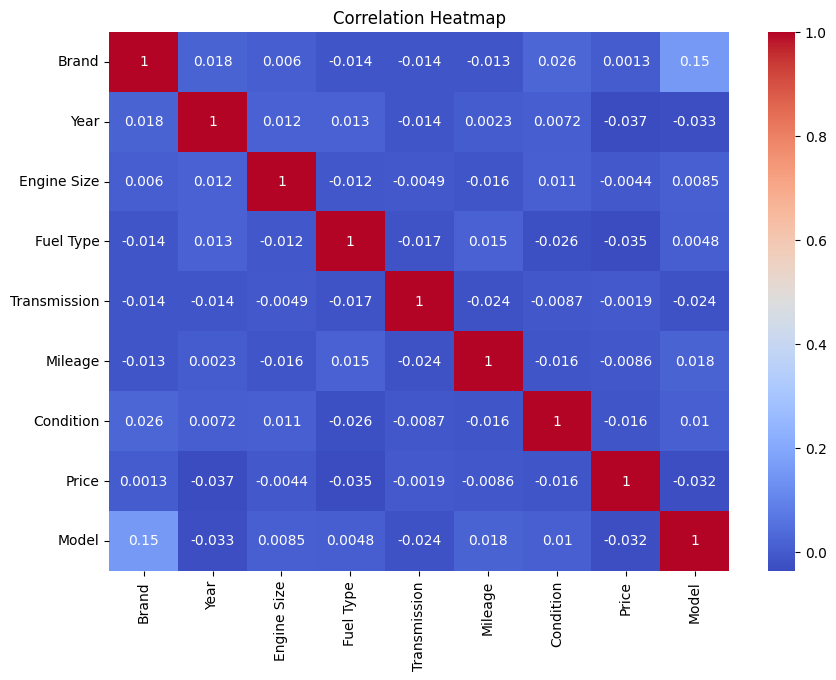

In [25]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [26]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2000, 8)
Testing Shape: (500, 8)


In [28]:
model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [29]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[61020.19733333 50677.03188455 54259.80026549 45753.03485981
 50677.03188455 46160.14921875 50677.03188455 50677.03188455
 48140.43288703 48140.43288703]


In [30]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 23455.445056676363
MSE : 758973446.7788323
RMSE: 27549.472713263178
R2 Score: -0.0018746066242416592


In [ ]:
importance = pd.DataFrame({   #select important features
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
5,Mileage,0.507776
2,Engine Size,0.155781
1,Year,0.129189
7,Model,0.055077
4,Transmission,0.054947
3,Fuel Type,0.054407
0,Brand,0.042824
6,Condition,0.000000


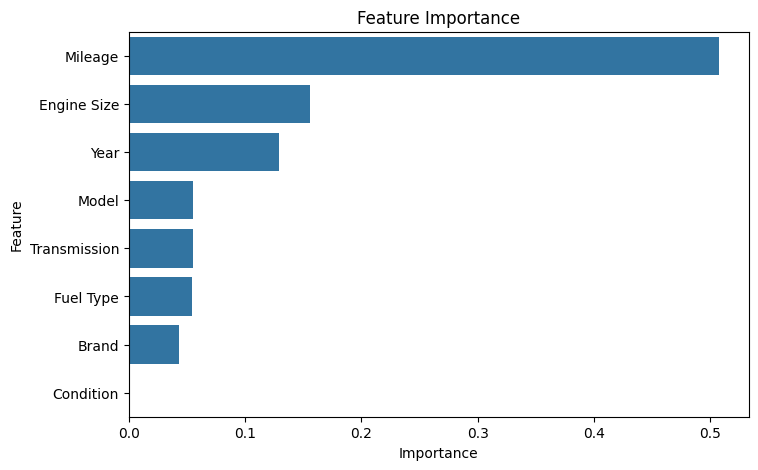

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=importance['Importance'],
    y=importance['Feature']
)

plt.title("Feature Importance")
plt.show()

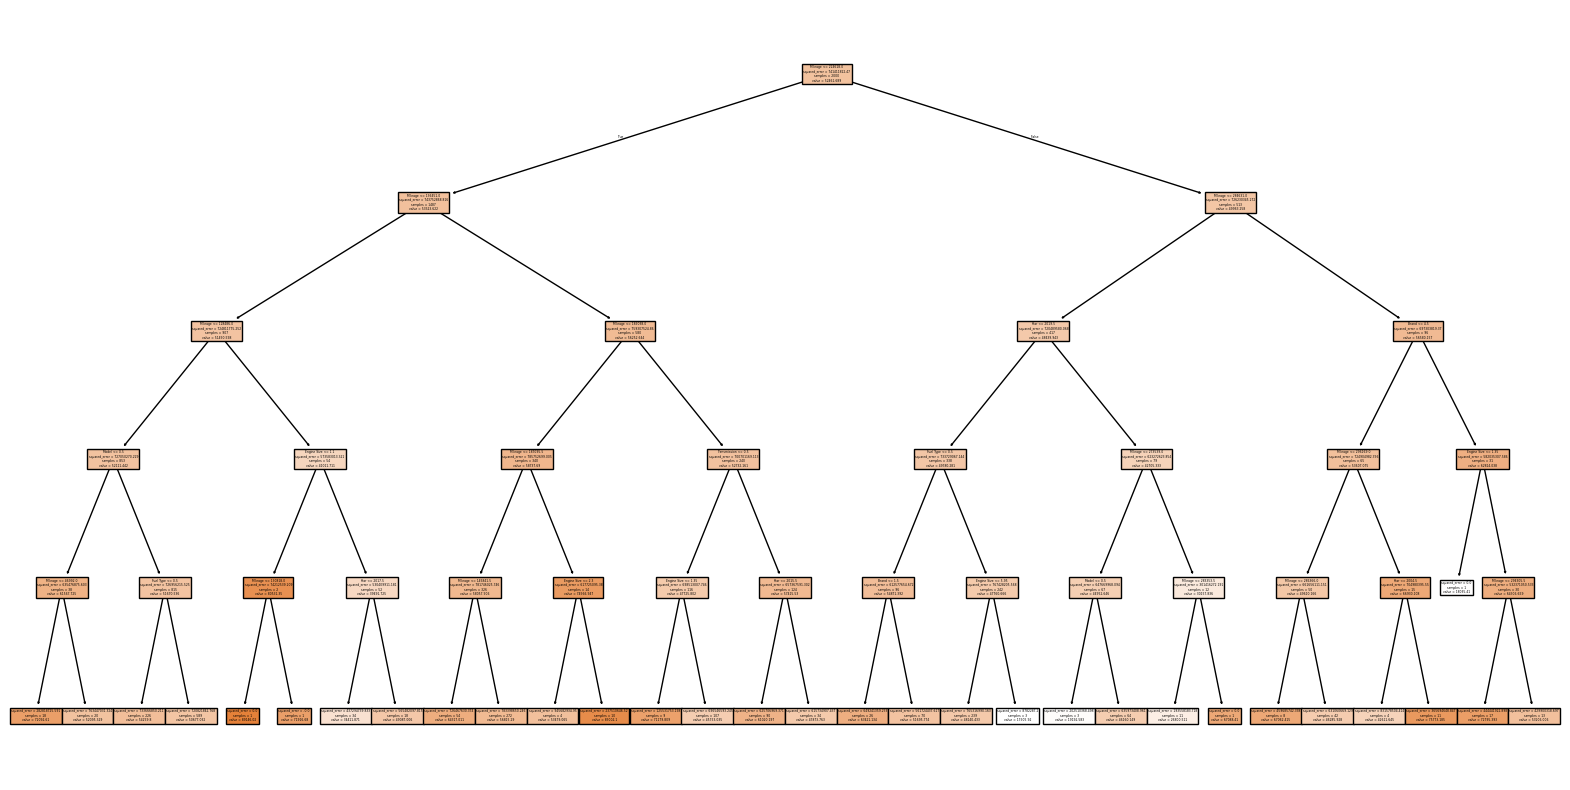

In [33]:
from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.show()